# Christine de Pizan - Entrainement et inférence

## Plan : 
- Renommer les images du dossier de "Pizan_line_train"
- Renommer les images du dossier "Pizan_fullpages_train"
- Crop des fullpages en blocs de texte
- Binarisation des images originellement déjà croppées
- Binarisation des images originellement non croppées
- Entrainement Resnet images originellement déjà croppées
- Entrainement Resnet images originellement non croppées
- Inférence données tests images originellement déjà croppées
- Inférence données tests images originellement non croppées


## Renommer les images du dossier  "Pizan_line_train"
- But : homogeneiser le noms de fichiers entre les différents corpus
- Formatage nom de fichier exemples : 
    - false_002573.jpg
    - aut_019570.jpg

In [3]:
import pandas as pd
df = pd.read_csv("data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/Pizan_lines_train.csv")

In [7]:
from PIL import Image
import random
import numpy as np
from pdf2image import convert_from_path
from pathlib import Path
import os
import shutil
import os
import pandas as pd
from tqdm import tqdm

# ── Chemins ────────────────────────────────────────────────────────────────────
BASE = "data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake"
SRC  = os.path.join(BASE, "Pizan_line_train")
DST  = os.path.join(BASE, "clean_line")
CSV  = os.path.join(BASE, "Pizan_lines_train.csv")

# ── 1. Créer le dossier clean_line et y copier tout le contenu de Pizan_line_train
if os.path.exists(DST):
    print(f"Le dossier '{DST}' existe déjà — la copie est ignorée.")
else:
    shutil.copytree(SRC, DST)
    print(f"Dossier dupliqué : '{SRC}' → '{DST}'")

# ── 2. Charger le CSV ──────────────────────────────────────────────────────────
df = pd.read_csv(CSV)

required_cols = {"filename", "Pizan"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Colonnes manquantes dans le CSV : {missing}")

label_map = {
    row["filename"]: "aut" if row["Pizan"] == "Pizan" else "false"
    for _, row in df.iterrows()
}

# ── 3. Renommer les fichiers dans clean_line ───────────────────────────────────
renamed   = 0
not_found = []

files = os.listdir(DST)

for fname in tqdm(files, desc="Renommage des fichiers", unit="fichier"):
    if fname not in label_map:
        not_found.append(fname)
        continue

    label    = label_map[fname]
    new_name = fname.replace("PIZAN_L_", f"{label}_", 1)

    os.rename(os.path.join(DST, fname), os.path.join(DST, new_name))
    renamed += 1

# ── 4. Rapport ─────────────────────────────────────────────────────────────────
print(f"\nFichiers renommés : {renamed}")

if not_found:
    print(f"\n{len(not_found)} fichier(s) sans correspondance dans le CSV :")
    for f in not_found:
        print(f"   • {f}")
else:
    print("Tous les fichiers avaient une correspondance dans le CSV.")

Dossier dupliqué : 'data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/Pizan_line_train' → 'data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/clean_line'


Renommage des fichiers: 100%|██████| 14848/14848 [00:02<00:00, 5609.88fichier/s]


Fichiers renommés : 14848
Tous les fichiers avaient une correspondance dans le CSV.


## Renommer les images du dossier "Pizan_fullpages_train"

In [ ]:
import shutil
import os
import pandas as pd
from tqdm import tqdm

# ── Chemins ────────────────────────────────────────────────────────────────────
BASE = "data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake"
SRC  = os.path.join(BASE, "Pizan_fullpages_train")
DST  = os.path.join(BASE, "clean_fullpage")
CSV  = os.path.join(BASE, "Pizan_fullpages_train.csv")

# ── 1. Créer le dossier clean_fullpage et y copier tout le contenu de Pizan_fullpages_train
if os.path.exists(DST):
    print(f"Le dossier '{DST}' existe déjà — la copie est ignorée.")
else:
    shutil.copytree(SRC, DST)
    print(f"Dossier dupliqué : '{SRC}' → '{DST}'")

# ── 2. Charger le CSV ──────────────────────────────────────────────────────────
df = pd.read_csv(CSV)

required_cols = {"filename", "Pizan"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Colonnes manquantes dans le CSV : {missing}")

label_map = {
    row["filename"]: "aut" if row["Pizan"] == "Pizan" else "false"
    for _, row in df.iterrows()
}

# ── 3. Renommer les fichiers dans clean_fullpage ───────────────────────────────
renamed   = 0
not_found = []

files = os.listdir(DST)

for fname in tqdm(files, desc="Renommage des fichiers", unit="fichier"):
    if fname not in label_map:
        not_found.append(fname)
        continue

    label    = label_map[fname]
    new_name = fname.replace("PIZAN_", f"{label}_", 1)  # ou "PIZAN_F_" si ton préfixe est différent

    os.rename(
        os.path.join(DST, fname),
        os.path.join(DST, new_name)
    )
    renamed += 1

# ── 4. Rapport ─────────────────────────────────────────────────────────────────
print(f"\nFichiers renommés : {renamed}")

if not_found:
    print(f"\n{len(not_found)} fichier(s) sans correspondance dans le CSV :")
    for f in not_found:
        print(f"   • {f}")
else:
    print("Tous les fichiers avaient une correspondance dans le CSV.")

## Crop des fullpages en blocs de texte

- Dossier output contenant les crops des fullpages : clean_fullpage_to_line

In [ ]:
import os
from PIL import Image
import numpy as np
from doctr.io import DocumentFile
from doctr.models import detection_predictor
from doctr.utils.geometry import detach_scores
import cv2
import matplotlib.pyplot as plt

# ── Paramètres ─────────────────────────────────────────────────────────────────
# Dossier contenant les images pleines pages
INPUT_DIR = "data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/clean_fullpage"
# Dossier de sortie pour les blocs de texte
OUTPUT_DIR = "data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/clean_fullpage_to_line"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Modèle de détection
det_predictor = detection_predictor(
    arch="fast_base",
    pretrained=True,
    assume_straight_pages=True,
    symmetric_pad=True,
    preserve_aspect_ratio=True,
    batch_size=1,
)

# ── Fonction utilitaire : coordonnées relatives → absolues ─────────────────────
def _to_absolute(geom, img_shape: tuple[int, int]) -> list[list[int]]:
    h, w = img_shape
    if len(geom) == 2:
        (xmin, ymin), (xmax, ymax) = geom
        xmin, xmax = int(round(w * xmin)), int(round(w * xmax))
        ymin, ymax = int(round(h * ymin)), int(round(h * ymax))
        return [[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]]
    else:
        return [[int(point[0] * w), int(point[1] * h)] for point in geom]

# ── 2. Boucle sur toutes les images du dossier clean_fullpage ─────────────────
for fname in os.listdir(INPUT_DIR):
    input_path = os.path.join(INPUT_DIR, fname)
    if not os.path.isfile(input_path) or not fname.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    print(f"Traitement de : {fname}")

    # Charger l'image
    img = cv2.imread(input_path)
    if img is None:
        print(f"Échec du chargement de {fname}")
        continue

    # Charger via doctr
    docs = DocumentFile.from_images([input_path])
    results = det_predictor(docs)

    # Compteur de blocs pour cette image
    block_id = 1
    for doc, res in zip(docs, results):
        img_shape = (doc.shape[0], doc.shape[1])
        detached_coords, prob_scores = detach_scores([res.get("words")])

        for coords in detached_coords[0]:
            # Convertir les coords en polygon
            if coords.shape == (4,):
                coords = coords.reshape(2, 2).tolist()

            points = np.array(_to_absolute(coords, img_shape), dtype=np.int32).reshape((-1, 1, 2))

            # Encochez le rectangle (xmin, ymin, xmax, ymax)
            xs = points[:, 0, 0]
            ys = points[:, 0, 1]
            xmin, ymin = xs.min(), ys.min()
            xmax, ymax = xs.max(), ys.max()

            # Cropper la zone de texte
            h, w = img.shape[:2]
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(w, xmax)
            ymax = min(h, ymax)

            if xmax <= xmin or ymax <= ymin:
                continue

            text_block = img[ymin:ymax, xmin:xmax]

            # Nom du fichier de sortie
            # par exemple : aut_000001_1.jpg
            base, ext = os.path.splitext(fname)
            output_name = f"{base}_{block_id}{ext}"
            output_path = os.path.join(OUTPUT_DIR, output_name)

            # Sauvegarder le bloc de texte
            cv2.imwrite(output_path, text_block)

            block_id += 1

## Binarisation des images originellement déjà croppées

In [ ]:
from pathlib import Path

directory = Path("data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/clean_line")

files = [f for f in directory.rglob("*") if f.is_file()]
print(f"Nombre total de fichiers : {len(files)}")

In [ ]:
from pathlib import Path
import random
import numpy as np
import cv2
from skimage.filters import threshold_sauvola
from scipy import ndimage
from tqdm.auto import tqdm

# Dossier d'entrée
input_dir = Path("data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/clean_line")
output_dir = Path("data/ICDAR/Christine de Pizan/binarized_20k")
output_dir.mkdir(parents=True, exist_ok=True)

img_exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

window_size = 51
k = 0.20
closing_kernel = 2


# 1. Charger toutes les images
files = [
    f
    for f in input_dir.rglob("*")
    if f.suffix.lower() in img_exts
]

if len(files) < 20_000:
    print(f" Seulement {len(files)} images trouvées ; toutes seront binarisées.")
    n = len(files)
else:
    n = 20_000
    print(f"Binarisation de {n} images...")
    files = random.sample(files, n)

# 2. Binariser + remplissage des trous + sauvegarde
for fpath in tqdm(files, total=n, desc="Binarisation"):
    img = cv2.imread(str(fpath))
    if img is None:
        print(f"Impossible de lire: {fpath}")
        continue

    # BGR → gray
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img.copy()

    # Sauvola + noir sur blanc (texte noir, fond blanc)
    th = threshold_sauvola(img_gray, window_size=window_size, k=k)
    binary = (img_gray >= th).astype(np.uint8) * 255

    # Fermeture morphologique
    if closing_kernel > 0:
        kernel = np.ones((closing_kernel, closing_kernel), np.uint8)
        binary = ndimage.binary_closing(binary > 0, structure=kernel).astype(np.uint8) * 255

    # Remplissage des trous
    binary_inv = 255 - binary
    filled = 255 - cv2.morphologyEx(
        binary_inv,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    )
    final = np.minimum(binary, filled)

    # Sauvegarde
    out_path = output_dir / f"{fpath.stem}_bin.png"
    cv2.imwrite(str(out_path), final)

print("Binarisation terminée.")

## Binarisation des images originellement non croppées

In [ ]:
import glob
import os

directory = "data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/clean_fullpage_to_line"
files = glob.glob(os.path.join(directory, "**", "*.*"), recursive=True)
print(f"Nombre total de fichiers : {len(files)}")

In [ ]:
from pathlib import Path
import random
import numpy as np
import cv2
from skimage.filters import threshold_sauvola
from scipy import ndimage
from tqdm.auto import tqdm

# Dossier d'entrée
input_dir = Path("data/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/clean_fullpage_to_line")
output_dir = Path("data/ICDAR/Christine de Pizan/binarized_1B")
output_dir.mkdir(parents=True, exist_ok=True)

img_exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

window_size = 51
k = 0.20
closing_kernel = 2


# 1. Charger toutes les images
files = [
    f
    for f in input_dir.rglob("*")
    if f.suffix.lower() in img_exts
]

if len(files) < 1_000_000:
    print(f"Seulement {len(files)} images trouvées ; toutes seront binarisées.")
    n = len(files)
else:
    n = 1_000_000
    print(f"👾 Binarisation de {n} images...")
    files = random.sample(files, n)

# 2. Binariser + remplissage des trous + sauvegarde
for fpath in tqdm(files, total=n, desc="Binarisation"):
    img = cv2.imread(str(fpath))
    if img is None:
        print(f"Impossible de lire: {fpath}")
        continue

    # BGR → gray
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img.copy()

    # Sauvola + noir sur blanc (texte noir, fond blanc)
    th = threshold_sauvola(img_gray, window_size=window_size, k=k)
    binary = (img_gray >= th).astype(np.uint8) * 255

    # Fermeture morphologique
    if closing_kernel > 0:
        kernel = np.ones((closing_kernel, closing_kernel), np.uint8)
        binary = ndimage.binary_closing(binary > 0, structure=kernel).astype(np.uint8) * 255

    # Remplissage des trous
    binary_inv = 255 - binary
    filled = 255 - cv2.morphologyEx(
        binary_inv,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    )
    final = np.minimum(binary, filled)

    # Sauvegarde
    out_path = output_dir / f"{fpath.stem}_bin.png"
    cv2.imwrite(str(out_path), final)

print("Binarisation terminée.")

## Entrainement Resnet images originellement déjà croppées

In [ ]:
import os
import random
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from pdf2image import convert_from_path

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    'data_dir': 'FalseID/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/binarized_20k',
    'cache_dir': './processed_images_cache',
    'batch_size': 16,
    'lr': 1e-4,
    'epochs': 15,
    'seed': 42,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'model_path': './best_resnet_paleo.pth'
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])
os.makedirs(CONFIG['cache_dir'], exist_ok=True)

# ==========================================
# 1. LISTE DE TOUS LES FICHIERS
# ==========================================
def load_all_files(base_dir, seed=42):
    random.seed(seed)

    aut_files = [f for f in os.listdir(base_dir) if f.startswith('aut_')]
    false_files = [f for f in os.listdir(base_dir) if f.startswith('false_')]

    all_files = [(os.path.join(base_dir, f), 1) for f in aut_files] + \
                [(os.path.join(base_dir, f), 0) for f in false_files]

    random.shuffle(all_files)
    print(f"Total fichiers trouvés : {len(all_files)}")
    return all_files

def split_train_val_test(all_files, seed=42):
    random.seed(seed)
    random.shuffle(all_files)

    n_total = len(all_files)
    n_test = int(0.10 * n_total)
    test_files = all_files[:n_test]
    trainval_files = all_files[n_test:]

    n_trainval = len(trainval_files)
    n_val = int(0.1111111111 * n_trainval)  # pour avoir environ 10% du total en val
    val_files = trainval_files[:n_val]
    train_files = trainval_files[n_val:]

    print(f"   Split :")
    print(f"   Train : {len(train_files)}")
    print(f"   Val   : {len(val_files)}")
    print(f"   Test  : {len(test_files)}")

    return train_files, val_files, test_files

# ==========================================
# 2. PRÉ-TRAITEMENT ET CACHE
# ==========================================
def preprocess_and_cache(file_label_list, cache_dir):
    print(f"🔄 Vérification et conversion des fichiers dans {cache_dir}...")
    valid_files = []

    for file_path, label in tqdm(file_label_list, desc="Préparation des données"):
        fname = os.path.basename(file_path)
        file_root, ext = os.path.splitext(fname)

        if ext.lower() == '.pdf':
            cached_file = os.path.join(cache_dir, file_root + ".jpg")
            if not os.path.exists(cached_file):
                try:
                    pages = convert_from_path(file_path, dpi=200, first_page=1, last_page=1)
                    pages[0].save(cached_file, 'JPEG')
                except Exception as e:
                    print(f"Erreur conversion {fname}: {e}")
                    continue
            final_path = cached_file
        else:
            final_path = file_path

        valid_files.append((final_path, label))

    return valid_files

# ==========================================
# 3. DATASET
# ==========================================
class PadToSquare:
    def __call__(self, img):
        w, h = img.size
        max_side = max(w, h)
        pad_w = (max_side - w) // 2
        pad_h = (max_side - h) // 2
        return transforms.functional.pad(
            img,
            (pad_w, pad_h, max_side - w - pad_w, max_side - h - pad_h),
            fill=255
        )

class PaleoDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        try:
            image = Image.open(path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color=(255, 255, 255))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

base_transforms = transforms.Compose([
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# ==========================================
# 4. SPLIT AVANT ENTRAÎNEMENT
# ==========================================
all_files = load_all_files(CONFIG['data_dir'], CONFIG['seed'])
train_files, val_files, test_files = split_train_val_test(all_files, CONFIG['seed'])

train_files = preprocess_and_cache(train_files, CONFIG['cache_dir'])
val_files = preprocess_and_cache(val_files, CONFIG['cache_dir'])
test_files = preprocess_and_cache(test_files, CONFIG['cache_dir'])

print(f"   Après prétraitement :")
print(f"   Train : {len(train_files)}")
print(f"   Val   : {len(val_files)}")
print(f"   Test  : {len(test_files)}")

train_ds = PaleoDataset(train_files, transform=base_transforms)
val_ds = PaleoDataset(val_files, transform=base_transforms)
test_ds = PaleoDataset(test_files, transform=base_transforms)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

# ==========================================
# 5. MODÈLE
# ==========================================
print("Chargement du modèle CNN (ResNet18)...")
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs, 2)
)
model = model.to(CONFIG['device'])

# ==========================================
# 6. ENTRAÎNEMENT
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

best_acc = 0.0
print(f"Début de l'entraînement sur {CONFIG['device']}")

for epoch in range(CONFIG['epochs']):
    model.train()
    train_preds, train_targets = [], []
    train_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]")
    for images, labels in loop:
        images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())
        loop.set_postfix(loss=loss.item())

    model.eval()
    val_loss = 0.0
    val_preds, val_targets = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_targets, train_preds)
    val_acc = accuracy_score(val_targets, val_preds)
    val_f1 = f1_score(val_targets, val_preds, average='weighted', zero_division=0)
    avg_val_loss = val_loss / max(1, len(val_loader))

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), CONFIG['model_path'])
        print(f"  Meilleur modèle sauvegardé : {best_acc:.4f}")

    scheduler.step(avg_val_loss)
    print(
        f"Epoch {epoch+1}: "
        f"Train Acc={train_acc:.4f} | "
        f"Val Loss={avg_val_loss:.4f} | "
        f"Val Acc={val_acc:.4f} | "
        f"Val F1={val_f1:.4f}"
    )

print("  Entraînement terminé")

# ==========================================
# 7. CHARGER LE MEILLEUR MODÈLE
# ==========================================
print("Chargement du meilleur modèle...")
state_dict = torch.load(CONFIG['model_path'], map_location=CONFIG['device'])
model.load_state_dict(state_dict)
model = model.to(CONFIG['device'])
model.eval()

# ==========================================
# 8. ÉVALUATION SUR TEST
# ==========================================
test_preds, test_targets = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Évaluation test"):
        images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(test_targets, test_preds)
test_precision = precision_score(test_targets, test_preds, average='weighted', zero_division=0)
test_recall = recall_score(test_targets, test_preds, average='weighted', zero_division=0)
test_f1 = f1_score(test_targets, test_preds, average='weighted', zero_division=0)
cm = confusion_matrix(test_targets, test_preds)

print("\n=== MÉTRIQUES SUR LE TEST ===")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-score  : {test_f1:.4f}")

print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(
    test_targets,
    test_preds,
    target_names=['false', 'aut'],
    zero_division=0
))

# ==========================================
# 9. MATRICE DE CONFUSION
# ==========================================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['false', 'aut'],
    yticklabels=['false', 'aut']
)
plt.xlabel('Prédictions')
plt.ylabel('Vraies classes')
plt.title('Matrice de confusion sur le test')
plt.tight_layout()
plt.show()

## Entrainement Resnet images originellement non croppées

- Voir fichier python "Pizan_entrainement_1B.py"

### Evaluation sur données test

/mnt/rex/home17/cjollivetcourtois/.envs/comp/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Chargement de data/ICDAR/Christine de Pizan/test_list.csv…
   96766 blocs | 3520 pages

 Chargement du modèle depuis data/ICDAR/Christine de Pizan/best_resnet_paleo.pth…
 Modèle prêt


Inférence: 100%|████████████████████████████| 1512/1512 [00:44<00:00, 33.67it/s]



═══════════════════════════════════════════════════════
📊 MÉTRIQUES NIVEAU BLOC
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

        FAKE     0.9829    0.9804    0.9817     50488
   AUTHENTIC     0.9787    0.9814    0.9801     46278

    accuracy                         0.9809     96766
   macro avg     0.9808    0.9809    0.9809     96766
weighted avg     0.9809    0.9809    0.9809     96766

═══════════════════════════════════════════════════════
📊 MÉTRIQUES NIVEAU PAGE (vote majoritaire)
═══════════════════════════════════════════════════════
Pages : 3520  |  Auth : 1328  |  Fake : 2192
              precision    recall  f1-score   support

        FAKE     1.0000    1.0000    1.0000      2192
   AUTHENTIC     1.0000    1.0000    1.0000      1328

    accuracy                         1.0000      3520
   macro avg     1.0000    1.0000    1.0000      3520
weighted avg     1.0000    1.0000    1.0000      3520



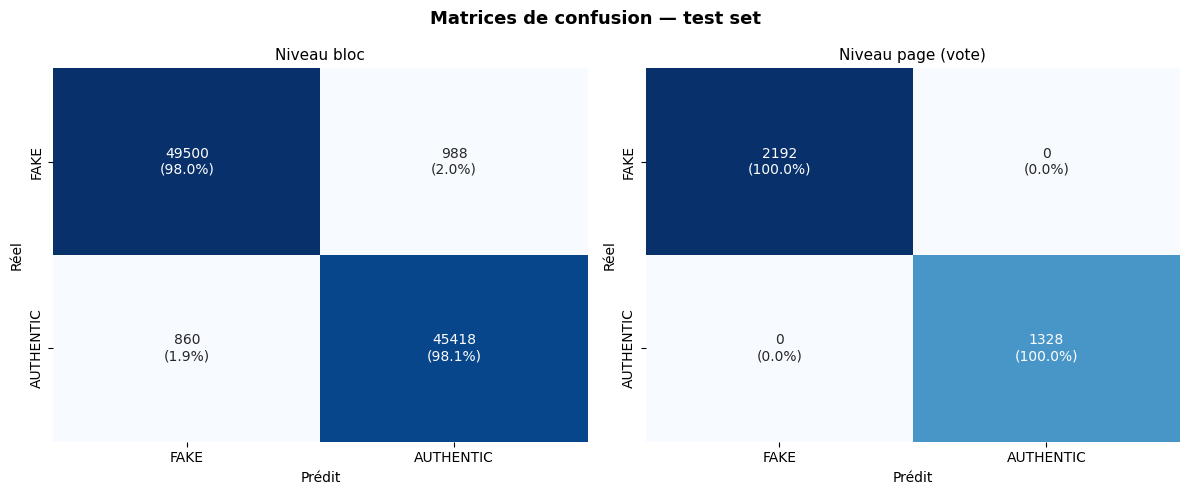


 Figure → data/ICDAR/Christine de Pizan/test_confusion_matrices.png
 Prédictions sauvegardées (blocs + pages)

 Évaluation terminée.


In [1]:
"""
Évaluation du meilleur modèle sur le test set.
Métriques au niveau bloc (prédiction unitaire) et page (vote majoritaire).
"""

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

# ──────────────────────────────────────────────────────────────
# CONFIGURATION 
# ──────────────────────────────────────────────────────────────
OUT_DIR        = Path("data/ICDAR/Christine de Pizan")
TEST_CSV       = "data/ICDAR/Christine de Pizan/test_list.csv"
MODEL_PATH     = "data/ICDAR/Christine de Pizan/best_resnet_paleo.pth"
BATCH_SIZE     = 64
NUM_WORKERS    = 4
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ──────────────────────────────────────────────────────────────
# DATASET
# ──────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class PadToSquare:
    def __call__(self, img):
        w, h = img.size
        m = max(w, h)
        pw, ph = (m - w) // 2, (m - h) // 2
        return transforms.functional.pad(img, (pw, ph, m - w - pw, m - h - ph), fill=255)

eval_transforms = transforms.Compose([
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class PaleoDataset(Dataset):
    def __init__(self, df, transform=None):
        self.data = df[["path", "label"]].values.tolist()
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), color=(255, 255, 255))
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# ──────────────────────────────────────────────────────────────
# CHARGEMENT DES DONNÉES
# ──────────────────────────────────────────────────────────────
print(f" Chargement de {TEST_CSV}…")
df_test = pd.read_csv(TEST_CSV)
df_test["origin"] = df_test["origin"].str.rsplit("_", n=1).str[0]
print(f"   {len(df_test)} blocs | {df_test['origin'].nunique()} pages")

dataset    = PaleoDataset(df_test, transform=eval_transforms)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

# ──────────────────────────────────────────────────────────────
# CHARGEMENT DU MODÈLE
# ──────────────────────────────────────────────────────────────
print(f"\n Chargement du modèle depuis {MODEL_PATH}…")
model = resnet18(weights=None)
model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(model.fc.in_features, 2))
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print(" Modèle prêt")

# ──────────────────────────────────────────────────────────────
# INFÉRENCE
# ──────────────────────────────────────────────────────────────
all_preds, all_targets = [], []

with torch.no_grad():
    for images, labels in tqdm(dataloader, desc="Inférence"):
        images = images.to(DEVICE)
        preds  = model(images).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

df_test["y_pred"] = all_preds

# ──────────────────────────────────────────────────────────────
# MÉTRIQUES NIVEAU BLOC
# ──────────────────────────────────────────────────────────────
print("\n" + "═"*55)
print("📊 MÉTRIQUES NIVEAU BLOC")
print("═"*55)
print(classification_report(
    df_test["label"], df_test["y_pred"],
    target_names=["FAKE", "AUTHENTIC"], labels=[0, 1], digits=4,
))

# ──────────────────────────────────────────────────────────────
# MÉTRIQUES NIVEAU PAGE (vote majoritaire)
# ──────────────────────────────────────────────────────────────
df_pages = (
    df_test
    .groupby("origin")
    .agg(
        y_true  = ("label",  "first"),
        y_pred  = ("y_pred", lambda x: x.mode()[0]),
        n_blocs = ("y_pred", "count"),
    )
    .reset_index()
)

print("═"*55)
print("📊 MÉTRIQUES NIVEAU PAGE (vote majoritaire)")
print("═"*55)
print(f"Pages : {len(df_pages)}  |  "
      f"Auth : {(df_pages.y_true==1).sum()}  |  "
      f"Fake : {(df_pages.y_true==0).sum()}")
print(classification_report(
    df_pages["y_true"], df_pages["y_pred"],
    target_names=["FAKE", "AUTHENTIC"], labels=[0, 1], digits=4,
))

# Pages mal classées
errors = df_pages[df_pages["y_true"] != df_pages["y_pred"]]
if len(errors):
    print(f" {len(errors)} page(s) mal classée(s) :")
    print(errors[["origin", "y_true", "y_pred", "n_blocs"]].to_string(index=False))

# ──────────────────────────────────────────────────────────────
# FIGURES
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Matrices de confusion — test set", fontsize=13, fontweight="bold")

for ax, (y_true, y_pred, title) in zip(axes, [
    (df_test["label"],   df_test["y_pred"],   "Niveau bloc"),
    (df_pages["y_true"], df_pages["y_pred"],  "Niveau page (vote)"),
]):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    # Afficher aussi les pourcentages dans chaque cellule
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot  = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
                        for row_v, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                xticklabels=["FAKE", "AUTHENTIC"],
                yticklabels=["FAKE", "AUTHENTIC"],
                ax=ax, cbar=False)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.tight_layout()
fig_path = OUT_DIR / "test_confusion_matrices.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n Figure → {fig_path}")

# Sauvegarder les prédictions
df_test.to_csv(OUT_DIR / "test_predictions_blocs.csv",  index=False)
df_pages.to_csv(OUT_DIR / "test_predictions_pages.csv", index=False)
print(" Prédictions sauvegardées (blocs + pages)")
print("\n Évaluation terminée.")

## Inférence données tests images originellement déjà croppées

In [22]:
import os
import glob
import csv
import random
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

# =========================
# CONFIGURATION
# =========================
INPUT_DIR = "Test_folder/clean_images_pour_inference/clean_snippets_test_bin"
MODEL_PATH = "./best_resnet_paleo.pth"
OUTPUT_CSV = "./output/Pizan_snippets_predictions.csv"
BATCH_SIZE = 16
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# =========================
# TRANSFORMATIONS
# =========================
class PadToSquare:
    def __call__(self, img):
        w, h = img.size
        max_side = max(w, h)
        pad_w = (max_side - w) // 2
        pad_h = (max_side - h) // 2
        return transforms.functional.pad(
            img,
            (pad_w, pad_h, max_side - w - pad_w, max_side - h - pad_h),
            fill=255
        )

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

base_transforms = transforms.Compose([
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# =========================
# LISTE DE TOUS LES FICHIERS
# =========================
def load_all_files(folder):
    files = []
    for p in sorted(glob.glob(os.path.join(folder, "*"))):
        if os.path.isfile(p):
            files.append(p)
    print(f"✅ Total fichiers trouvés : {len(files)}")
    return files

# =========================
# DATASET INFERENCE
# =========================
class InferDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            image = Image.open(path).convert("RGB")
        except:
            image = Image.new("RGB", (224, 224), color=(255, 255, 255))

        if self.transform:
            image = self.transform(image)

        return image, os.path.basename(path)

# =========================
# MODÈLE
# =========================
print("Chargement du modèle...")
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs, 2)
)

state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

# =========================
# INFÉRENCE
# =========================
files = load_all_files(INPUT_DIR)

dataset = InferDataset(files, transform=base_transforms)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

rows = []

with torch.no_grad():
    for images, names in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        for name, pred in zip(names, preds):
            # 1 = non authentique, 0 = authentique
            rows.append([name, int(pred)])

# =========================
# SAUVEGARDE CSV
# =========================
with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["filename", "prediction"])
    writer.writerows(rows)

print(f"CSV enregistré dans : {OUTPUT_CSV}")

Chargement du modèle...
✅ Total fichiers trouvés : 7425
CSV enregistré dans : ./output/Pizan_snippets_predictions.csv


In [24]:
# supprimer "_bin" du nom de fichier dans les csv
import pandas as pd

csv_path = "./output/Pizan_snippets_predictions.csv"

df = pd.read_csv(csv_path)

df["filename"] = df["filename"].str.replace("_bin.png", ".png", regex=False)

df.to_csv(csv_path, index=False)

print(f"CSV mis à jour : {csv_path}")

CSV mis à jour : ./output/Pizan_snippets_predictions.csv


In [39]:
df = pd.read_csv("./output/Pizan_snippets_predictions.csv")
df.head()

,filename,pred
0,PIZAN_L_000004.png,1
1,PIZAN_L_000005.png,0
2,PIZAN_L_000006.png,1
3,PIZAN_L_000007.png,1
4,PIZAN_L_000008.png,1


### Clean labels

In [27]:
# ajout de la colonne "pred"
df["pred"] = 1 - df["prediction"]
df.head()

,filename,prediction,pred
0,PIZAN_L_000004.png,0,1
1,PIZAN_L_000005.png,1,0
2,PIZAN_L_000006.png,0,1
3,PIZAN_L_000007.png,0,1
4,PIZAN_L_000008.png,0,1


In [30]:
# suppression de l'ancienne colonne 
df = df.drop(columns=["prediction"])

In [31]:
df.head()

,filename,pred
0,PIZAN_L_000004.png,1
1,PIZAN_L_000005.png,0
2,PIZAN_L_000006.png,1
3,PIZAN_L_000007.png,1
4,PIZAN_L_000008.png,1


In [ ]:
df.to_csv("./output/Pizan_pages_predictions.csv", index=False)

In [53]:
df = pd.read_csv("./output/Pizan_snippets_predictions.csv")
df.head()

,filename,pred
0,PIZAN_L_000004.png,1
1,PIZAN_L_000005.png,0
2,PIZAN_L_000006.png,1
3,PIZAN_L_000007.png,1
4,PIZAN_L_000008.png,1


In [54]:
df["filename"] = df["filename"].str.replace(".png", ".jpg", regex=False)

In [55]:
df.head()

,filename,pred
0,PIZAN_L_000004.jpg,1
1,PIZAN_L_000005.jpg,0
2,PIZAN_L_000006.jpg,1
3,PIZAN_L_000007.jpg,1
4,PIZAN_L_000008.jpg,1


In [56]:
df.to_csv("./output/Pizan_snippets_predictions.csv", index=False)

## Inférence données tests images originellement non croppées

In [57]:
import os
import random
import re
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18

# ============================================================
# CONFIGURATION
# ============================================================
INPUT_DIR   = Path("Test_folder/clean_images_pour_inference/clean_fullpages_to_line_test_bin")
MODEL_PATH  = Path("best_resnet_paleo2.pth")
OUTPUT_CSV  = Path("./output/Pizan_pages_predictions.csv")
BATCH_SIZE  = 64
NUM_WORKERS = 4
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

# ============================================================
# SEED
# ============================================================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

# ============================================================
# TRANSFORMS
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class PadToSquare:
    def __call__(self, img):
        w, h = img.size
        m = max(w, h)
        pw, ph = (m - w) // 2, (m - h) // 2
        return transforms.functional.pad(
            img,
            (pw, ph, m - w - pw, m - h - ph),
            fill=255
        )

eval_transforms = transforms.Compose([
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ============================================================
# LISTE DES FICHIERS
# ============================================================
def get_origin_name(filename: str):
    stem = Path(filename).stem
    origin = re.sub(r'_\d+_bin$', '', stem)
    return origin

def build_inference_list(folder: Path):
    rows = []
    for p in sorted(folder.iterdir()):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            origin = get_origin_name(p.name)
            rows.append((str(p), origin))
    print(f"Nombre de fichiers trouvés : {len(rows)}")
    print(f"Nombre d'images d'origine : {pd.Series([r[1] for r in rows]).nunique() if rows else 0}")
    return rows

# ============================================================
# DATASET
# ============================================================
class InferDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, origin = self.data[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), color=(255, 255, 255))
        if self.transform:
            img = self.transform(img)
        return img, origin, os.path.basename(path)

# ============================================================
# MODÈLE
# ============================================================
print("Chargement du modèle...")
model = resnet18(weights=None)
model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.fc.in_features, 2)
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print("Modèle prêt")

# ============================================================
# INFÉRENCE BLOC
# ============================================================
data_list = build_inference_list(INPUT_DIR)
dataset = InferDataset(data_list, transform=eval_transforms)
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

all_rows = []

with torch.no_grad():
    for images, origins, filenames in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        for fn, origin, pred in zip(filenames, origins, preds):
            all_rows.append({
                "filename": fn,
                "origin": origin,
                "y_pred_block": int(pred)
            })

df_blocks = pd.DataFrame(all_rows)

# ============================================================
# AGRÉGATION AU NIVEAU IMAGE D'ORIGINE
# ============================================================
def majority_vote(s):
    m = s.mode()
    return int(m.iloc[0]) if len(m) else 0

df_pages = (
    df_blocks
    .groupby("origin")
    .agg(
        y_pred=("y_pred_block", majority_vote),
        n_blocs=("y_pred_block", "count"),
    )
    .reset_index()
)

# ============================================================
# SAUVEGARDE CSV
# ============================================================
df_pages[["origin", "y_pred", "n_blocs"]].rename(
    columns={"origin": "filename", "y_pred": "prediction"}
).to_csv(OUTPUT_CSV, index=False)

print(f"CSV sauvegardé : {OUTPUT_CSV}")
print(df_pages.head())

Chargement du modèle...
Modèle prêt
Nombre de fichiers trouvés : 652909
Nombre d'images d'origine : 2482
CSV sauvegardé : output/Pizan_pages_predictions.csv
         origin  y_pred  n_blocs
0  PIZAN_003522       0      217
1  PIZAN_003523       1      462
2  PIZAN_003524       0      212
3  PIZAN_003525       1      233
4  PIZAN_003526       0      254


In [58]:
df = pd.read_csv("./output/Pizan_pages_predictions.csv")

In [59]:
df.head()

,filename,prediction,n_blocs
0,PIZAN_003522,0,217
1,PIZAN_003523,1,462
2,PIZAN_003524,0,212
3,PIZAN_003525,1,233
4,PIZAN_003526,0,254


## Clean labels

In [60]:
df = pd.read_csv("./output/Pizan_pages_predictions.csv")
df.head()

,filename,prediction,n_blocs
0,PIZAN_003522,0,217
1,PIZAN_003523,1,462
2,PIZAN_003524,0,212
3,PIZAN_003525,1,233
4,PIZAN_003526,0,254


In [61]:
# ajout de la colonne "pred"
df["pred"] = 1 - df["prediction"]
df.head()


,filename,prediction,n_blocs,pred
0,PIZAN_003522,0,217,1
1,PIZAN_003523,1,462,0
2,PIZAN_003524,0,212,1
3,PIZAN_003525,1,233,0
4,PIZAN_003526,0,254,1


In [62]:
# suppression de l'ancienne colonne 
df = df.drop(columns=["prediction"])


In [63]:
df.head()

,filename,n_blocs,pred
0,PIZAN_003522,217,1
1,PIZAN_003523,462,0
2,PIZAN_003524,212,1
3,PIZAN_003525,233,0
4,PIZAN_003526,254,1


In [64]:
df.to_csv("./output/Pizan_pages_predictions.csv", index=False)

In [65]:
df = pd.read_csv("./output/Pizan_pages_predictions.csv")
df.head()

,filename,n_blocs,pred
0,PIZAN_003522,217,1
1,PIZAN_003523,462,0
2,PIZAN_003524,212,1
3,PIZAN_003525,233,0
4,PIZAN_003526,254,1


In [66]:
df["filename"] = df["filename"].astype(str) + ".jpg"

In [67]:
df.to_csv("./output/Pizan_pages_predictions.csv", index=False)

In [68]:
df = pd.read_csv("./output/Pizan_pages_predictions.csv")
df.head()

,filename,n_blocs,pred
0,PIZAN_003522.jpg,217,1
1,PIZAN_003523.jpg,462,0
2,PIZAN_003524.jpg,212,1
3,PIZAN_003525.jpg,233,0
4,PIZAN_003526.jpg,254,1


In [69]:
# suppression de la colonne "n_blocs"
df = df.drop(columns=["n_blocs"])

In [70]:
df.to_csv("./output/Pizan_pages_predictions.csv", index=False)

In [71]:
df = pd.read_csv("./output/Pizan_pages_predictions.csv")
df.head()

,filename,pred
0,PIZAN_003522.jpg,1
1,PIZAN_003523.jpg,0
2,PIZAN_003524.jpg,1
3,PIZAN_003525.jpg,0
4,PIZAN_003526.jpg,1
